<a href="https://colab.research.google.com/github/OscarW99/applied-ml-series/blob/main/ClassicalML1_2_EndToEnd_BreastCancerClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EndToEnd_BreastCancerClassification**

This notebook walks through an end-to-end machine learning project for classifying breast cancer tumors as malignant or benign using the Wisconsin Breast Cancer dataset from Scikit-learn.



---
# 1. Loading the Data



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load the dataset
cancer = load_breast_cancer()
print(dir(cancer))
print(cancer.DESCR)
print(cancer.data)


['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']
.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  F

In [2]:

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:

df['diagnosis'] = (cancer.target == 0).astype(int)

print("Dataset loaded successfully.")
print(f"Shape of the dataset: {df.shape}")



print("\nOriginal Scikit-learn target unique values:", np.unique(cancer.target))
print("Our 'diagnosis' column unique values:", np.unique(df['diagnosis']))
print("Counts for our 'diagnosis' column:")
print(df['diagnosis'].value_counts())

Dataset loaded successfully.
Shape of the dataset: (569, 31)

Original Scikit-learn target unique values: [0 1]
Our 'diagnosis' column unique values: [0 1]
Counts for our 'diagnosis' column:
diagnosis
0    357
1    212
Name: count, dtype: int64


---
# 2. Initial Data Exploration & Visualization



In [4]:
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset info (columns, data types, non-null counts):")
df.info()

print("\nStatistical summary of numerical features:")
print(df.describe())


First 5 rows of the dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter

 Plot histograms for all numerical features, separated by diagnosis

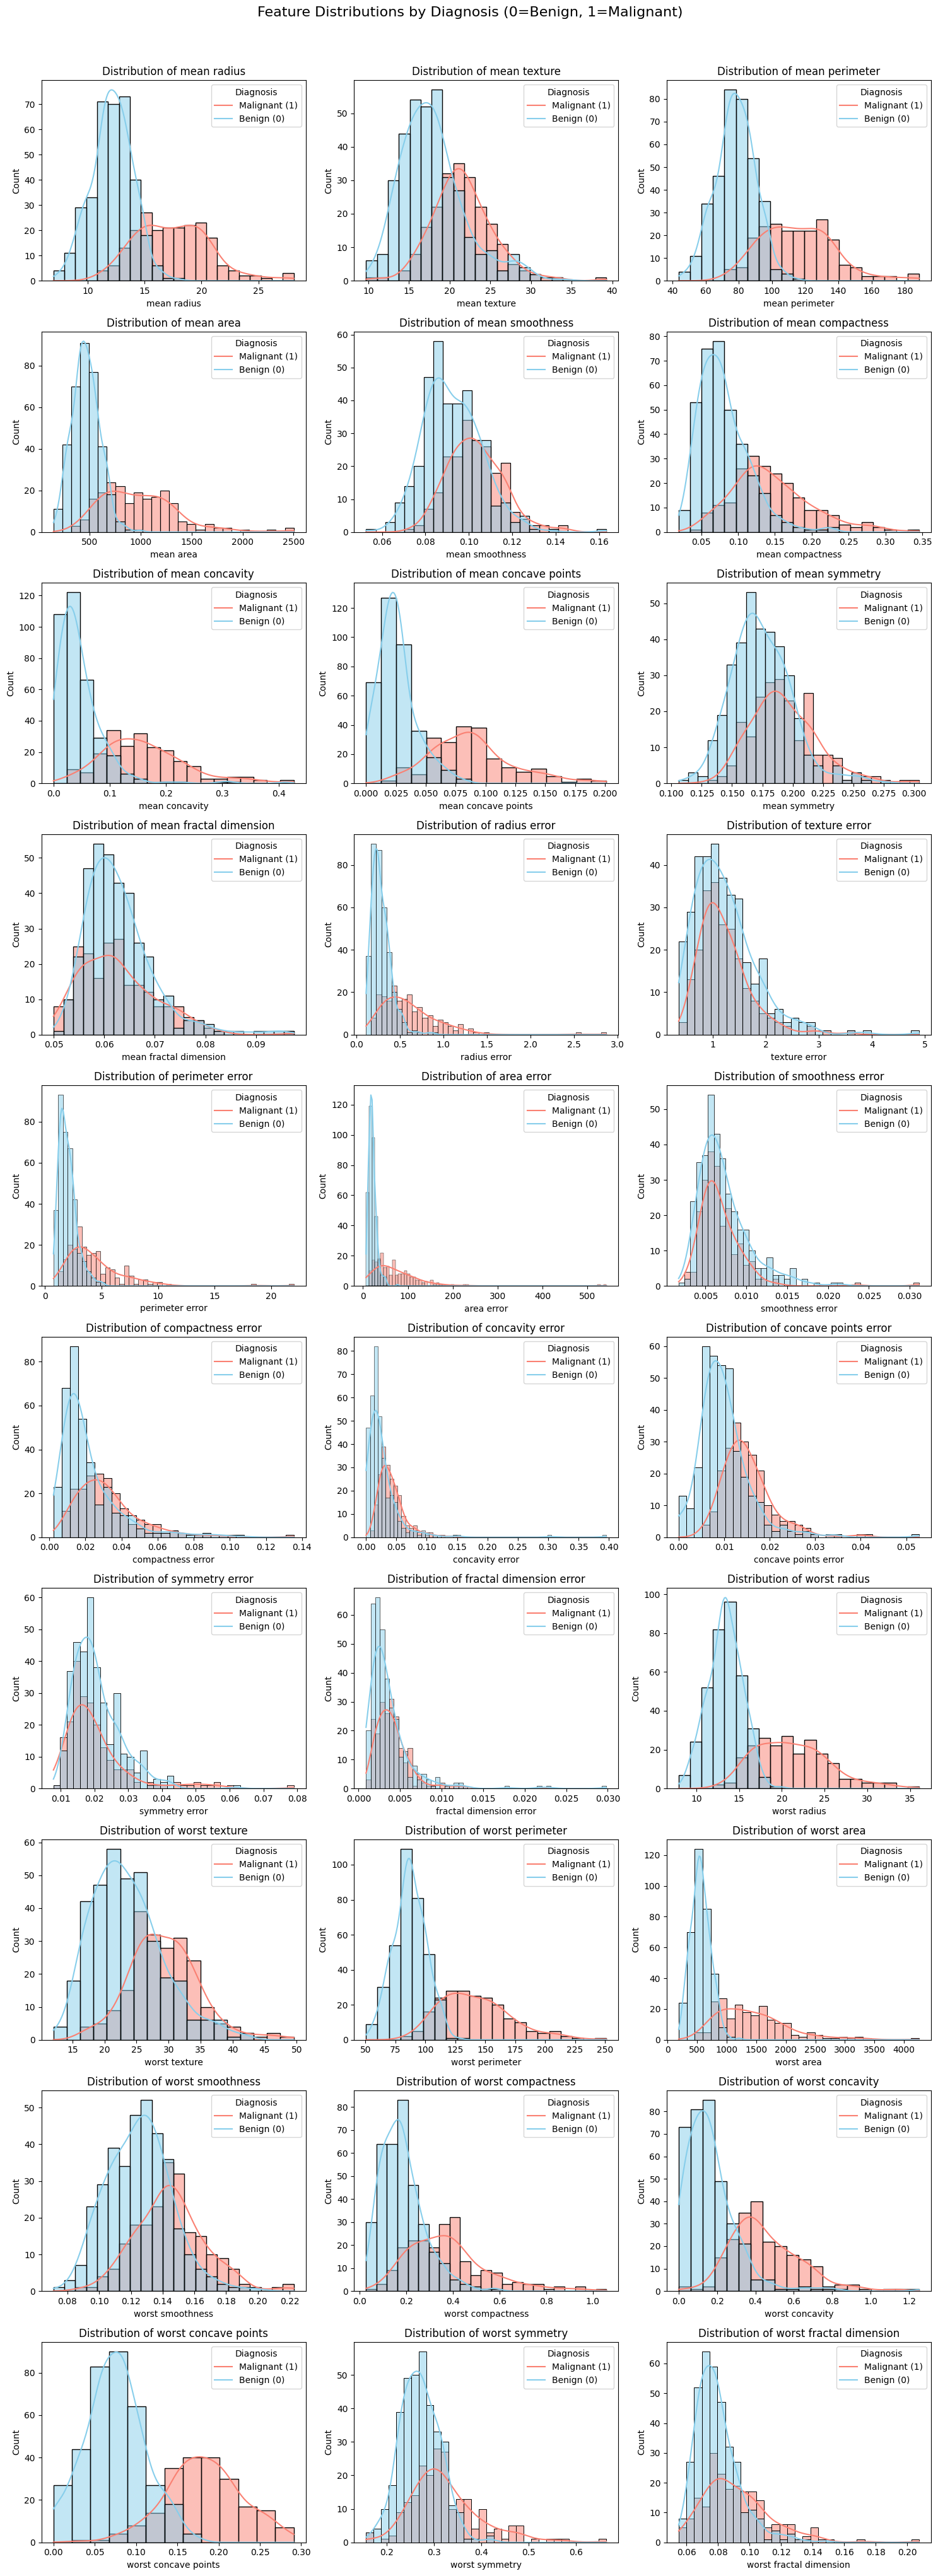

In [5]:
numerical_features = df.drop('diagnosis', axis=1).columns


n_features = len(numerical_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, ax=axes[i], palette={0: 'skyblue', 1: 'salmon'})
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].legend(title='Diagnosis', labels=['Malignant (1)', 'Benign (0)'])


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Feature Distributions by Diagnosis (0=Benign, 1=Malignant)", fontsize=16, y=1.02)
plt.show()

---
# 3. Split into Training and Test Sets



In [6]:
from sklearn.model_selection import train_test_split


X = df.drop('diagnosis', axis=1)
y = df['diagnosis']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")
print("\nTraining set diagnosis distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest set diagnosis distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (455, 30), Test set shape: (114, 30)

Training set diagnosis distribution:
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Test set diagnosis distribution:
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


---
# 4. Deeper Exploration & Visualization on the Training Set



**UMAP Visualization**



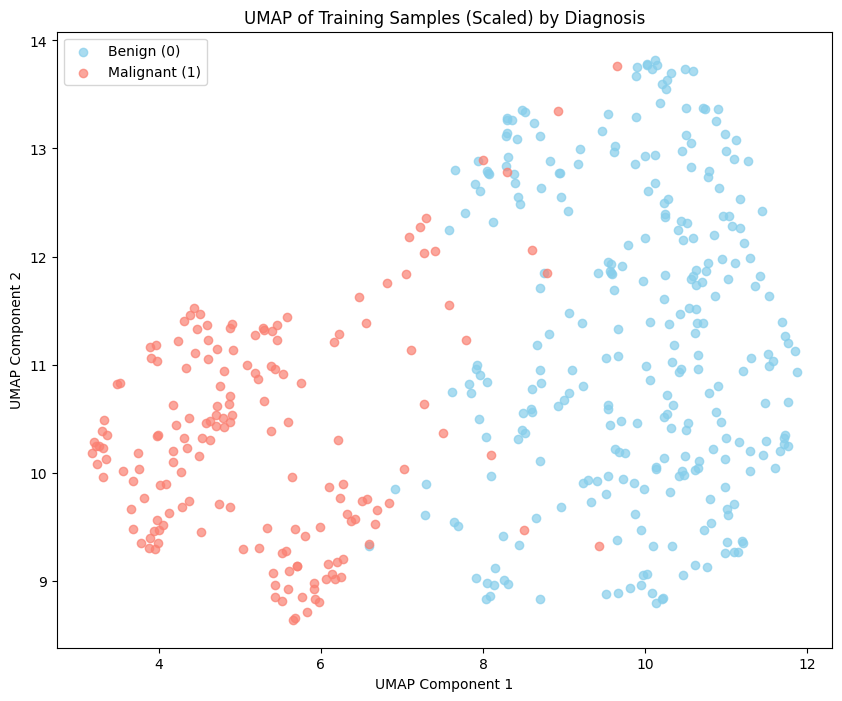

In [7]:

try:
    from sklearn.preprocessing import StandardScaler
    from umap import UMAP


    X_train_scaled_for_umap = StandardScaler().fit_transform(X_train)

    reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, n_jobs=1)
    X_train_umap = reducer.fit_transform(X_train_scaled_for_umap)

    plt.figure(figsize=(10, 8))

    plt.scatter(X_train_umap[y_train==0, 0], X_train_umap[y_train==0, 1], label="Benign (0)", c="skyblue", alpha=0.7)
    plt.scatter(X_train_umap[y_train==1, 0], X_train_umap[y_train==1, 1], label="Malignant (1)", c="salmon", alpha=0.7)
    plt.xlabel("UMAP Component 1")
    plt.ylabel("UMAP Component 2")
    plt.title("UMAP of Training Samples (Scaled) by Diagnosis")
    plt.legend()
    plt.show()
except ImportError:
    print("UMAP not installed or an issue occurred. Skipping UMAP plot.")
    print("To install UMAP: !pip install umap-learn (run this in a new code cell if needed)")



### **Correlation Analysis on Training Data**



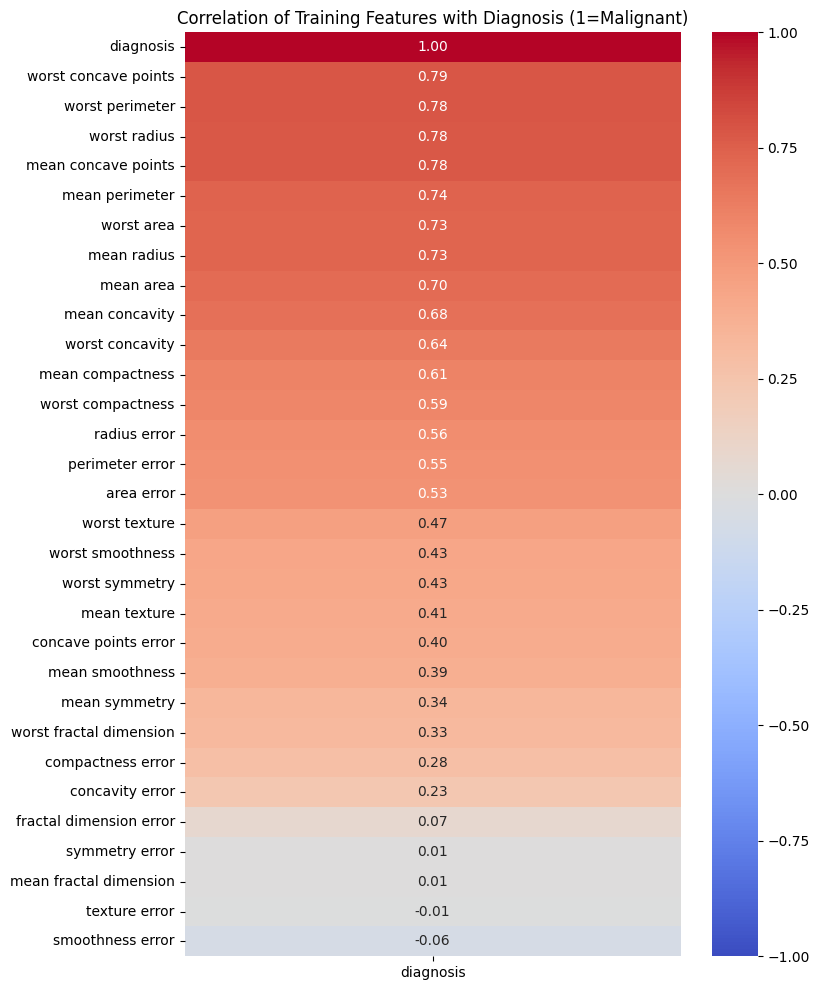


Top Positive Correlations with Diagnosis (Training Data):
diagnosis               1.000000
worst concave points    0.786306
worst perimeter         0.782881
worst radius            0.777602
mean concave points     0.775737
mean perimeter          0.740027
worst area              0.731761
mean radius             0.728160
mean area               0.703893
mean concavity          0.683688
Name: diagnosis, dtype: float64

Top Negative Correlations (actually least positive here):
fractal dimension error    0.070343
symmetry error             0.006430
mean fractal dimension     0.005534
texture error             -0.006663
smoothness error          -0.056654
Name: diagnosis, dtype: float64


In [8]:

X_train_with_target = X_train.copy()
X_train_with_target['diagnosis'] = y_train

corr_matrix_train = X_train_with_target.corr()


plt.figure(figsize=(8, 12))
sns.heatmap(corr_matrix_train[['diagnosis']].sort_values(by='diagnosis', ascending=False), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation of Training Features with Diagnosis (1=Malignant)")
plt.show()


sorted_corr_train = corr_matrix_train["diagnosis"].sort_values(ascending=False)
print("\nTop Positive Correlations with Diagnosis (Training Data):")
print(sorted_corr_train.head(10))
print("\nTop Negative Correlations (actually least positive here):")
print(sorted_corr_train.tail(5))


Top features selected for PairPlot: ['worst concave points', 'worst perimeter', 'worst radius', 'mean concave points']


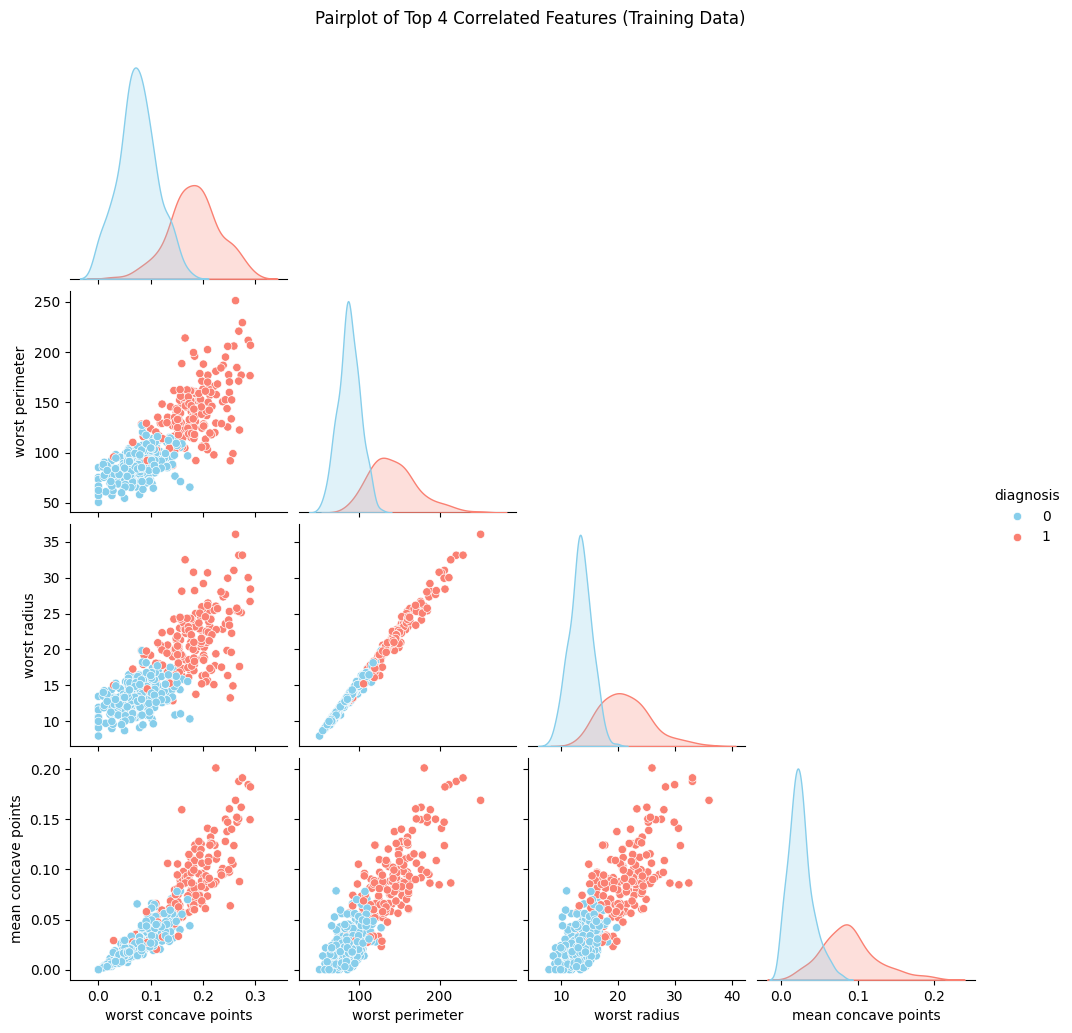

In [9]:
from pandas.plotting import scatter_matrix
top_features_for_pairplot = [f for f in sorted_corr_train.index if f != 'diagnosis'][:4]

print(f"\nTop features selected for PairPlot: {top_features_for_pairplot}")

if top_features_for_pairplot:
    sns.pairplot(X_train_with_target, vars=top_features_for_pairplot, hue='diagnosis',
                 palette={0: 'skyblue', 1: 'salmon'}, corner=True)

    plt.gcf().suptitle(f"Pairplot of Top {len(top_features_for_pairplot)} Correlated Features (Training Data)", y=1.03)
    plt.show()
else:
    print("No features selected for pairplot based on correlation, skipping.")

---
# 5. Prepare the Data for Machine Learning Algorithms



### **Handling Missing Values (Illustrative)**


In [10]:
from sklearn.impute import SimpleImputer


X_train_temp_for_imputation = X_train.copy()

for i in range(min(5, len(X_train_temp_for_imputation))):
    X_train_temp_for_imputation.iloc[i, X_train_temp_for_imputation.columns.get_loc('mean texture')] = np.nan

print("NaNs in 'mean texture' (temp df) before imputation:", X_train_temp_for_imputation['mean texture'].isnull().sum())


imputer = SimpleImputer(strategy="median")


imputer.fit(X_train_temp_for_imputation[['mean texture']])

X_train_temp_for_imputation['mean texture'] = imputer.transform(X_train_temp_for_imputation[['mean texture']])

print("NaNs in 'mean texture' (temp df) AFTER imputation:", X_train_temp_for_imputation['mean texture'].isnull().sum())
print("First 5 'mean texture' values (temp df) after imputation with median:")
print(X_train_temp_for_imputation['mean texture'].head())
print("\n(End of illustrative imputation. We'll use the original clean X_train going forward.)")

NaNs in 'mean texture' (temp df) before imputation: 5
NaNs in 'mean texture' (temp df) AFTER imputation: 0
First 5 'mean texture' values (temp df) after imputation with median:
10     18.89
170    18.89
407    18.89
430    18.89
27     18.89
Name: mean texture, dtype: float64

(End of illustrative imputation. We'll use the original clean X_train going forward.)


### **Feature Scaling**

 using `StandardScaler`.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


num_pipeline_example = Pipeline([
    ('std_scaler', StandardScaler()),
])
X_train_prepared_np_example = num_pipeline_example.fit_transform(X_train)

print(f"\nShape of X_train after example scaling: {X_train_prepared_np_example.shape}")
print("A few values from X_train after example scaling (first 2 rows, first 5 cols):")
print(X_train_prepared_np_example[:2, :5])


X_train_prepared_df_example = pd.DataFrame(X_train_prepared_np_example, columns=X_train.columns, index=X_train.index)
print("\nMean of 'mean radius' after example scaling:", X_train_prepared_df_example['mean radius'].mean())
print("Std dev of 'mean radius' after example scaling:", X_train_prepared_df_example['mean radius'].std())
print("\n(Actual scaling will happen inside model pipelines on the fly.)")


Shape of X_train after example scaling: (455, 30)
A few values from X_train after example scaling (first 2 rows, first 5 cols):
[[ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371]
 [-0.51636409 -1.63971029 -0.54134872 -0.54296133  0.47621906]]

Mean of 'mean radius' after example scaling: -3.654219783909086e-15
Std dev of 'mean radius' after example scaling: 1.0011007157982694

(Actual scaling will happen inside model pipelines on the fly.)


---
# 6. Select and Train a Model



### **Baseline Model: Logistic Regression**

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(solver="liblinear", random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)


y_train_pred_log_reg = log_reg_pipeline.predict(X_train)
train_accuracy_log_reg = accuracy_score(y_train, y_train_pred_log_reg)
train_probas_log_reg = log_reg_pipeline.predict_proba(X_train)[:, 1]
train_auc_log_reg = roc_auc_score(y_train, train_probas_log_reg)
print(f"\nLogistic Regression TRAINING accuracy: {train_accuracy_log_reg:.4f}")
print(f"Logistic Regression TRAINING AUC: {train_auc_log_reg:.4f}")


Logistic Regression TRAINING accuracy: 0.9890
Logistic Regression TRAINING AUC: 0.9976




### **Decision Tree Classifier**

In [13]:
from sklearn.tree import DecisionTreeClassifier
tree_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("tree_clf", DecisionTreeClassifier(random_state=42))
])
tree_pipeline.fit(X_train, y_train)


y_train_pred_tree = tree_pipeline.predict(X_train)
train_accuracy_tree = accuracy_score(y_train, y_train_pred_tree)
train_probas_tree = tree_pipeline.predict_proba(X_train)[:, 1]
train_auc_tree = roc_auc_score(y_train, train_probas_tree)
print(f"\nDecision Tree TRAINING accuracy: {train_accuracy_tree:.4f}")
print(f"Decision Tree TRAINING AUC: {train_auc_tree:.4f}")


Decision Tree TRAINING accuracy: 1.0000
Decision Tree TRAINING AUC: 1.0000




### **Better Evaluation Using Cross-Validation**


In [15]:
from sklearn.model_selection import cross_val_score


log_reg_auc_scores_cv = cross_val_score(log_reg_pipeline, X_train, y_train, cv=10, scoring="roc_auc")
print(f"\nLogistic Regression 10-fold CV AUC scores: {log_reg_auc_scores_cv.round(4)}")
print(f"Mean CV AUC: {log_reg_auc_scores_cv.mean():.4f}, Std CV AUC: {log_reg_auc_scores_cv.std():.4f}")


tree_auc_scores_cv = cross_val_score(tree_pipeline, X_train, y_train, cv=10, scoring="roc_auc")
print(f"\nDecision Tree 10-fold CV AUC scores: {tree_auc_scores_cv.round(4)}")
print(f"Mean CV AUC: {tree_auc_scores_cv.mean():.4f}, Std CV AUC: {tree_auc_scores_cv.std():.4f}")


Logistic Regression 10-fold CV AUC scores: [1.     1.     1.     1.     0.9736 0.9916 0.9979 1.     0.9895 1.    ]
Mean CV AUC: 0.9953, Std CV AUC: 0.0081

Decision Tree 10-fold CV AUC scores: [0.9655 0.9655 0.9828 0.9361 0.8529 0.8992 0.917  0.9055 0.8225 0.8697]
Mean CV AUC: 0.9117, Std CV AUC: 0.0498




### **Random Forest Classifier**


In [16]:
from sklearn.ensemble import RandomForestClassifier
forest_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("forest_clf", RandomForestClassifier(n_estimators=100, random_state=42))
])
forest_auc_scores_cv = cross_val_score(forest_pipeline, X_train, y_train, cv=10, scoring="roc_auc")
print(f"\nRandom Forest 10-fold CV AUC scores: {forest_auc_scores_cv.round(4)}")
print(f"Mean CV AUC: {forest_auc_scores_cv.mean():.4f}, Std CV AUC: {forest_auc_scores_cv.std():.4f}")


Random Forest 10-fold CV AUC scores: [1.     1.     1.     1.     0.9817 0.9653 1.     0.9979 0.9433 0.9958]
Mean CV AUC: 0.9884, Std CV AUC: 0.0185


---
# 7. Fine-Tune Model



In [17]:
from sklearn.model_selection import GridSearchCV


param_grid_rf = [
    {'forest_clf__n_estimators': [50, 100, 150],
     'forest_clf__max_features': ['sqrt', 'log2', None],
     'forest_clf__max_depth': [None, 10, 20],
     'forest_clf__min_samples_split': [2, 5, 10]}
]


forest_pipeline_for_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("forest_clf", RandomForestClassifier(random_state=42))
])

grid_search_rf = GridSearchCV(forest_pipeline_for_grid, param_grid_rf,
                              cv=5, scoring='roc_auc',
                              return_train_score=True, verbose=1, n_jobs=-1)

grid_search_rf.fit(X_train, y_train)

print("\nGridSearchCV Best Parameters (Random Forest):")
print(grid_search_rf.best_params_)
print(f"Best CV AUC score from GridSearchCV: {grid_search_rf.best_score_:.4f}")

best_rf_model_gs = grid_search_rf.best_estimator_

Fitting 5 folds for each of 81 candidates, totalling 405 fits

GridSearchCV Best Parameters (Random Forest):
{'forest_clf__max_depth': None, 'forest_clf__max_features': 'log2', 'forest_clf__min_samples_split': 2, 'forest_clf__n_estimators': 50}
Best CV AUC score from GridSearchCV: 0.9924



### **Analyzing the Best Models and Their Errors**



Top 10 Feature Importances (from best Random Forest):
worst radius: 0.1300
worst concave points: 0.1067
mean perimeter: 0.1027
worst area: 0.0861
mean concave points: 0.0674
mean area: 0.0570
area error: 0.0553
mean concavity: 0.0541
mean radius: 0.0526
worst perimeter: 0.0451


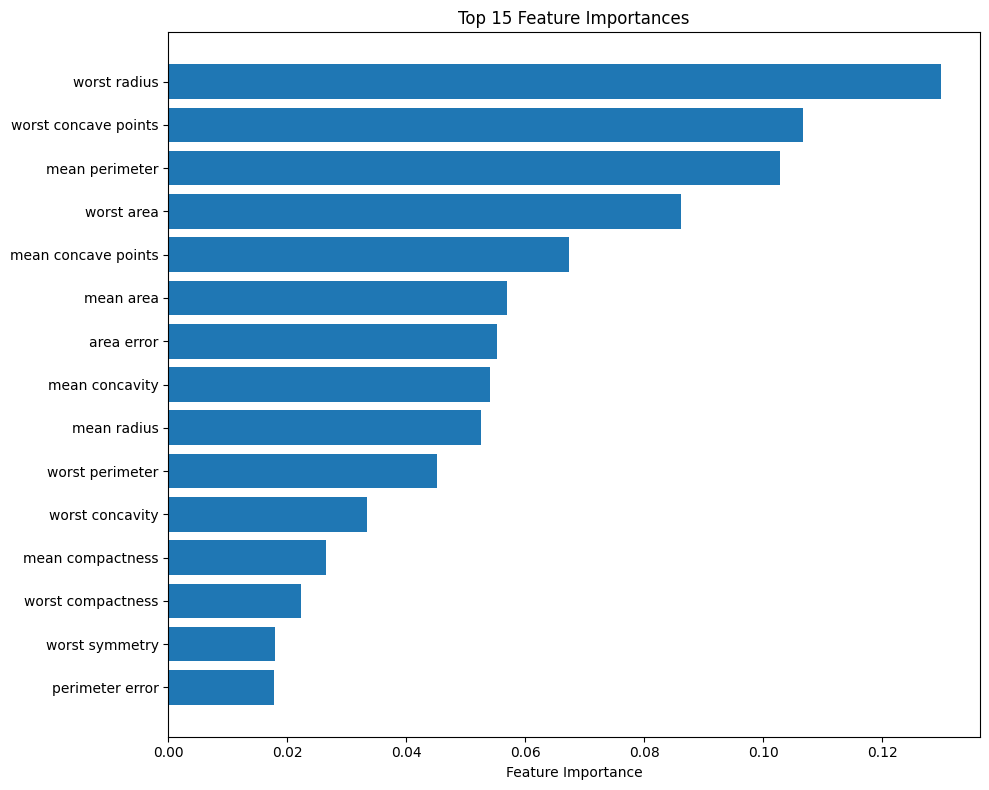

In [18]:

final_model_pipeline = best_rf_model_gs
final_model_classifier_step = final_model_pipeline.named_steps["forest_clf"]
feature_importances = final_model_classifier_step.feature_importances_

feature_names = X_train.columns

sorted_importances_with_names = sorted(zip(feature_importances, feature_names), reverse=True)

print("\nTop 10 Feature Importances (from best Random Forest):")
for importance, name in sorted_importances_with_names[:10]:
    print(f"{name}: {importance:.4f}")

plt.figure(figsize=(10, 8))
top_n = 15

names_for_plot = [name for imp, name in sorted_importances_with_names[:top_n]][::-1]
importances_for_plot = [imp for imp, name in sorted_importances_with_names[:top_n]][::-1]

plt.barh(names_for_plot, importances_for_plot)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()

---
# 8. Evaluate Your System on the Test Set




Final Model Performance on Test Set:
Test Accuracy: 0.9737
Test AUC: 0.9962

Confusion Matrix on Test Set (TN, FP / FN, TP):
[[72  0]
 [ 3 39]]


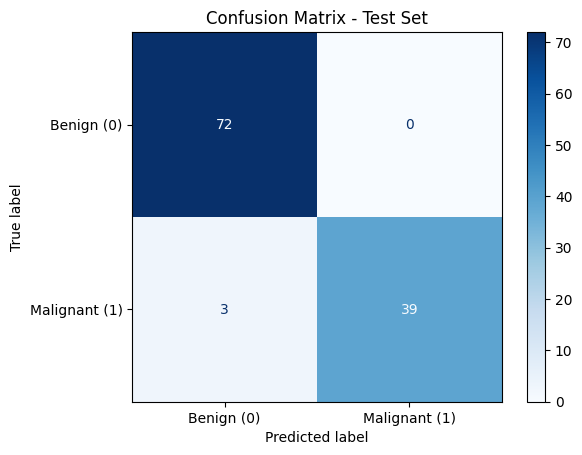

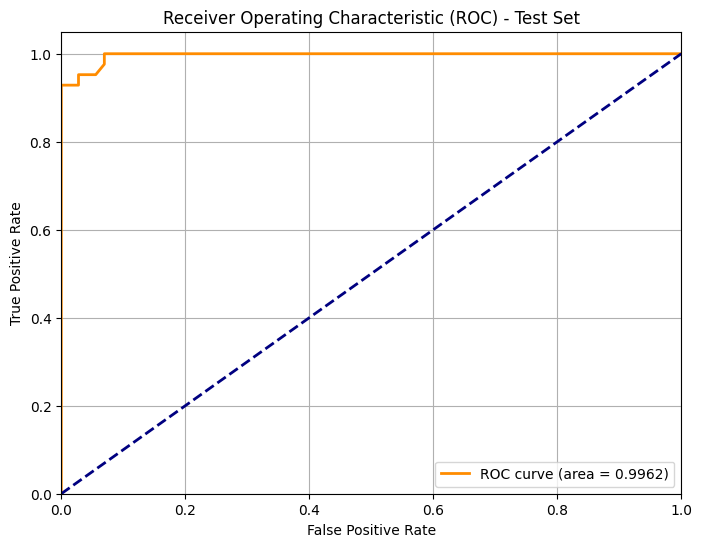

In [19]:
y_test_pred = final_model_pipeline.predict(X_test)
y_test_proba = final_model_pipeline.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"\nFinal Model Performance on Test Set:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

conf_matrix = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix on Test Set (TN, FP / FN, TP):")
print(conf_matrix)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()


fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Test Set')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

---
# 9. Launch, Monitor, and System Maintainance



In [20]:
import joblib

model_filename = "breast_cancer_classification_model.pkl"
joblib.dump(final_model_pipeline, model_filename)
print(f"\nModel saved as {model_filename}")




Model saved as breast_cancer_classification_model.pkl
